# Topic Modeling

**Topic Modeling** is an NLP technique used to discover the **main topics or themes** in a collection of documents.

The important idea is:

> **Topic Modeling automatically discovers what a group of documents is mainly about.**

Unlike **Sentiment Analysis**, which asks:

> "Is the text positive or negative?"

Topic Modeling asks:

> "What is this text about?"

---

## Example

Suppose we have these reviews:

```text
Review 1:
"The phone has an excellent camera and beautiful photos."

Review 2:
"The battery lasts all day and charges very quickly."

Review 3:
"The camera quality is amazing and the photos are very clear."

Review 4:
"The battery life is poor and the phone needs frequent charging."
```

A Topic Modeling algorithm might discover:

### Topic 1 — Camera

```text
camera, photos, quality, picture, image
```

### Topic 2 — Battery

```text
battery, charging, charge, power, life
```

The model discovers these topics **without us manually defining them**.

---

## How Does Topic Modeling Work?

A simplified workflow:

```text
Documents
    ↓
Text Cleaning
    ↓
Tokenization
    ↓
TF-IDF / Bag of Words
    ↓
Topic Modeling Algorithm
    ↓
Topics + Important Words
```

---

# Common Topic Modeling Algorithms

### 1. LDA

**LDA = Latent Dirichlet Allocation**

LDA is one of the most popular traditional Topic Modeling algorithms.

It assumes that:

* A document can contain **multiple topics**.
* A topic is represented by a group of related words.

For example:

```text
Document
   ↓
70% Technology
30% Business
```

---

### 2. NMF

**NMF = Non-negative Matrix Factorization**

NMF can also be used to discover topics from a collection of documents.

It works particularly well with **TF-IDF matrices**.


We can then interpret the topics:

```text
Topic 1 → Camera
Topic 2 → Battery
Topic 3 → Screen
```

---

# Topic Modeling vs Sentiment Analysis

| Task                   | Question                                    |
| ---------------------- | ------------------------------------------- |
| **Sentiment Analysis** | Is the text Positive, Negative, or Neutral? |
| **Topic Modeling**     | What is the text about?                     |
| **NER**                | What entities are mentioned?                |
| **POS Tagging**        | What is the grammatical type of each word?  |

### Example

```text
"The camera is amazing, but the battery is terrible."
```

**Sentiment Analysis:**

```text
Negative
```

**Topic Modeling:**

```text
Camera
Battery
```

**NER:**

Could identify entities such as:

```text
Apple → ORG
iPhone → PRODUCT
```

> **Topic Modeling = discovering hidden topics in a collection of documents.**


# Topic Modeling – Example

Let's take **one document** and see how it can be related to **3 different topics**.

## Example Document

> "The new smartphone has an excellent camera with high image quality. The battery lasts for more than 24 hours and supports fast charging. The device also has a powerful processor that provides excellent performance for gaming and running applications."

## Extracting Keywords

| Keywords     | Topic       |
| ------------ | ----------- |
| smartphone   | Technology  |
| camera       | Camera      |
| image        | Camera      |
| quality      | Camera      |
| battery      | Battery     |
| charging     | Battery     |
| 24 hours     | Battery     |
| processor    | Performance |
| gaming       | Performance |
| applications | Performance |
| performance  | Performance |

Based on these keywords, the document can be associated with **3 topics**.

### Topic 1 — Camera

**Keywords:**

```text
camera
image
quality
```

### Topic 2 — Battery

**Keywords:**

```text
battery
charging
24 hours
```

### Topic 3 — Performance

**Keywords:**

```text
processor
gaming
applications
performance
```

## Topic Distribution

A Topic Modeling algorithm such as **LDA** may determine that the document contains multiple topics:

```text
Document
   │
   ├── 40% Camera
   ├── 35% Battery
   └── 25% Performance
```

This is called the **Topic Distribution** of the document.

The document does **not** have to belong to only one topic. It can contain multiple topics with different proportions.

## How Does Topic Modeling Discover the Topics?

We don't tell the model beforehand:

```text
camera → Camera Topic
battery → Battery Topic
processor → Performance Topic
```

Instead, the model analyzes many documents and looks for words that frequently appear together.

For example:

```text
camera → image → photo → quality
```

The model may identify these words as a **Camera Topic**.

And:

```text
battery → charging → power → hours
```

may become a **Battery Topic**.

And:

```text
processor → gaming → performance → applications
```

may become a **Performance Topic**.

## Simple Definition

> **Topic Modeling discovers the hidden topics in a collection of documents by identifying groups of words that frequently occur together.**

**Keywords → help describe a topic**

**Document → can contain multiple topics**

**Topic Modeling → discovers these topics automatically**


In [21]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import gensim
import gensim.corpora as corpora

In [22]:
data = pd.read_csv("news_articles.csv") # data should be in the same folder as your notebook

In [23]:
data.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       100 non-null    int64 
 1   title    100 non-null    object
 2   content  100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


# Clean Data

In [25]:
# take just the content of the article, lowercase and remove punctuation
articles = data['content'].str.lower().apply(lambda x: re.sub(r"([^\w\s])", "", x))

# stop word removal
en_stopwords = stopwords.words('english')
articles = articles.apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

# tokenize
articles = articles.apply(lambda x: word_tokenize(x))

# stemming (done for speed as we have a lot of text)
ps = PorterStemmer()
articles = articles.apply(lambda tokens: [ps.stem(token) for token in tokens])

In [26]:
articles

0     [dr, frank, sack, professor, nutrit, harvard, ...
1     [south, carolina, win, duke, surpris, fan, pos...
2     [want, get, brief, email, here, good, even, he...
3     [banjul, gambia, week, inaugur, anoth, countri...
4     [biggest, book, summer, isnt, blockbust, thril...
                            ...                        
95    [want, get, brief, email, here, good, even, he...
96    [tallinn, estonia, guard, brought, ahm, abdul,...
97    [gov, scott, walker, wisconsin, activ, wiscons...
98    [social, media, shook, emot, headlin, shout, n...
99    [moment, joanna, acevedo, first, set, foot, bo...
Name: content, Length: 100, dtype: object

# Vectorization

In [27]:
# create dictionary of all words
dictionary = corpora.Dictionary(articles)
print(dictionary)

Dictionary<8693 unique tokens: ['10', '100', '108', '15', '155']...>


In [39]:
#print(dictionary.token2id)

In [29]:
# vecotize using bag of words into a document term matrix
doc_term = [dictionary.doc2bow(text) for text in articles]

In [40]:
#print(doc_term)

# LDA

In [31]:
# specify number of topics
num_topics = 2

In [32]:
# Create an LDA model for topic modeling
lda_model = gensim.models.LdaModel(
    corpus=doc_term,       # Document-term matrix
    id2word=dictionary,    # Map word IDs to actual words
    num_topics=num_topics  # Number of topics to discover
)

In [33]:
# Print the top 5 words for each topic
lda_model.print_topics(
    num_topics=num_topics,  # Number of topics to display
    num_words=5             # Number of top words per topic
)

[(0,
  '0.018*"mr" + 0.016*"said" + 0.005*"trump" + 0.005*"would" + 0.004*"year"'),
 (1,
  '0.015*"mr" + 0.013*"said" + 0.006*"trump" + 0.005*"one" + 0.005*"state"')]

# LSA and SVD in NLP

## 1. What is LSA?

**LSA = Latent Semantic Analysis**

LSA is an NLP technique used to discover **hidden topics and relationships between words and documents**.

The main idea is:

> **LSA takes a large text matrix and reduces it to a smaller number of latent dimensions using SVD.**

So:

```text
Text
 ↓
TF-IDF
 ↓
Text Matrix
 ↓
SVD
 ↓
LSA
 ↓
Latent Topics
```

---

# 2. Example

Suppose we have 3 documents:

```text
Document 1:
camera photo quality

Document 2:
battery charging power

Document 3:
camera photo battery
```

We can create a **Term-Document Matrix**:

| Word     | Doc 1 | Doc 2 | Doc 3 |
| -------- | ----: | ----: | ----: |
| camera   |     1 |     0 |     1 |
| photo    |     1 |     0 |     1 |
| quality  |     1 |     0 |     0 |
| battery  |     0 |     1 |     1 |
| charging |     0 |     1 |     0 |
| power    |     0 |     1 |     0 |

Our matrix contains:

```text
6 words × 3 documents
```

But we don't want to work with all these dimensions.

This is where **SVD** comes in.

---

# 3. What is SVD?

**SVD = Singular Value Decomposition**

SVD is a mathematical technique that **decomposes one matrix into three matrices**.

The main formula is:

```text
A = U Σ Vᵀ
```

Think of it as:

```text
Original Matrix
      A
      ↓
 ┌────┼────┐
 ↓    ↓    ↓
 U    Σ    Vᵀ
```

Each matrix has a different role.

---

# 4. Matrix U

`U` describes the relationship between:

> **Words and latent topics**

Suppose SVD discovers two latent dimensions:

```text
Topic 1 → Camera
Topic 2 → Battery
```

We may get something conceptually like:

| Word     | Camera Topic | Battery Topic |
| -------- | -----------: | ------------: |
| camera   |          0.9 |           0.1 |
| photo    |          0.8 |           0.1 |
| quality  |          0.7 |           0.0 |
| battery  |          0.1 |           0.9 |
| charging |          0.0 |           0.8 |
| power    |          0.0 |           0.7 |

So:

```text
camera  → strongly related to Camera Topic
photo   → strongly related to Camera Topic

battery → strongly related to Battery Topic
charging → strongly related to Battery Topic
```

### U → Words ↔ Topics

---

# 5. Matrix Σ (Sigma)

`Σ` contains the **Singular Values**.

These values tell us:

> **How important or strong each latent dimension is.**

For example:

```text
Σ =

5.8
3.2
0.4
0.1
```

We can interpret them as:

```text
5.8 → Very important
3.2 → Important
0.4 → Weak
0.1 → Very weak
```

So we can keep the important dimensions and remove the weak ones.

### Σ → Importance of latent dimensions

---

# 6. Matrix Vᵀ

`Vᵀ` describes the relationship between:

> **Documents and latent topics**

For example:

| Document | Camera Topic | Battery Topic |
| -------- | -----------: | ------------: |
| Doc 1    |         0.95 |          0.05 |
| Doc 2    |         0.05 |          0.95 |
| Doc 3    |         0.70 |          0.60 |

So:

```text
Doc 1 → mostly Camera
Doc 2 → mostly Battery
Doc 3 → Camera + Battery
```

### Vᵀ → Documents ↔ Topics

---

# 7. Why Do We Need SVD?

Imagine we have:

```text
10,000 words × 5,000 documents
```

That's a huge matrix.

We don't necessarily need all 10,000 dimensions.

SVD can reduce it:

```text
10,000 words × 5,000 documents
              ↓
             SVD
              ↓
       100 latent dimensions
```

Instead of representing the documents using thousands of word dimensions, we can represent them using a smaller number of **latent dimensions**.

---

# 8. What Does "Latent" Mean?

**Latent** means:

> **Hidden or underlying**

For example, our dataset doesn't contain a column called:

```text
Camera Topic
```

But we have words like:

```text
camera
photo
image
picture
quality
```

These words frequently occur together.

LSA can discover that they represent an underlying semantic concept.

So:

```text
camera
photo
image
picture
quality
       ↓
Camera Topic
```

Similarly:

```text
battery
charging
power
hours
life
       ↓
Battery Topic
```

These are **latent topics**.

---

# 9. LSA Uses SVD

This is the most important relationship:

```text
LSA
 │
 ↓
Create a Text Matrix
 │
 ↓
Apply SVD
 │
 ├── U
 │    ↓
 │  Words ↔ Topics
 │
 ├── Σ
 │    ↓
 │  Importance
 │
 └── Vᵀ
      ↓
   Documents ↔ Topics
```

So **SVD is the mathematical tool used by LSA**.

---

# 10. Truncated SVD

In practice, we usually don't keep all the dimensions.

We keep only the most important `k` dimensions.

This is called **Truncated SVD**.

Mathematically:

```text
A = U Σ Vᵀ
```

becomes approximately:

```text
A ≈ Uₖ Σₖ Vₖᵀ
```

The `k` means:

> **Keep only k important latent dimensions.**

For example:

```python
from sklearn.decomposition import TruncatedSVD

lsa = TruncatedSVD(
    n_components=3,
    random_state=42
)
```

Here:

```text
n_components = 3
```

means:

> Keep **3 latent dimensions**.

---

# 12. What Does `lsa_matrix` Represent?

Suppose we have:

```text
Document 1
Document 2
Document 3
```

After LSA:

```text
              Topic 1   Topic 2   Topic 3

Document 1      0.82      0.15      0.03
Document 2      0.10      0.91      0.05
Document 3      0.60      0.55      0.02
```

We can interpret this as:

```text
Document 1 → mostly Topic 1

Document 2 → mostly Topic 2

Document 3 → Topic 1 + Topic 2
```

So LSA gives us a **lower-dimensional representation of the documents**.

---


# 15. LSA vs LDA

Both can be used for **Topic Modeling**, but they work differently.

| LSA                       | LDA                              |
| ------------------------- | -------------------------------- |
| Uses SVD                  | Uses probability                 |
| Usually works with TF-IDF | Usually works with word counts   |
| Linear algebra based      | Probabilistic                    |
| Finds latent dimensions   | Finds probabilistic topics       |
| Uses `TruncatedSVD`       | Uses `LatentDirichletAllocation` |

### LSA

```text
Text
 ↓
TF-IDF
 ↓
SVD
 ↓
Latent Dimensions
```

### LDA

```text
Text
 ↓
Word Counts
 ↓
LDA
 ↓
Topics
```

---

# Final Picture

The whole idea can be summarized as:

```text
                DOCUMENTS
                    ↓
             Text Preprocessing
                    ↓
                  TF-IDF
                    ↓
            Text-Document Matrix
                    ↓
                  SVD
                    ↓
        ┌───────────┼───────────┐
        ↓           ↓           ↓
        U           Σ           Vᵀ
        ↓           ↓           ↓
      Words      Importance   Documents
        ↕           │           ↕
      Topics        │         Topics
                    ↓
          Keep important dimensions
                    ↓
              Latent Topics
```

### The Key Idea

> **LSA uses SVD to reduce a large TF-IDF text matrix into a smaller number of latent dimensions that capture important semantic patterns in the documents.**

### Remember

```text
LSA → What are the hidden semantic patterns?

SVD → The mathematical technique used to find them.

U → Words ↔ Topics

Σ → Importance of dimensions

Vᵀ → Documents ↔ Topics
```


In [34]:
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

In [35]:
# specify number of topics
num_topics = 2

In [36]:
# create LSA model
lsamodel = LsiModel(doc_term, num_topics=num_topics, id2word = dictionary) 
print(lsamodel.print_topics(num_topics=num_topics, num_words=5))

[(0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'), (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"')]


# CoherenceModel

`CoherenceModel` is used to **check the quality of the topics** created by our Topic Modeling model.

### Simple Idea

It asks:

> **Are the words in each topic related to each other?**

### Example

A good topic:

```text
camera
photo
image
picture
```

These words are related → **High Coherence**

A bad topic:

```text
camera
football
banana
school
```

These words are not related → **Low Coherence**

---

## Why Do We Use It?

We can use the **Coherence Score** to help choose the best number of topics.

```text
2 Topics  → 0.40
3 Topics  → 0.55
4 Topics  → 0.70  ← Best
5 Topics  → 0.60
```

So, we may choose **4 topics** because it has the highest coherence score.

### In One Line

> **CoherenceModel checks how related the words in each topic are.**


In [42]:
# Create an empty list to store the coherence scores
coherence_values = []

# Create an empty list to store the LSA models
model_list = []

# Set the minimum number of topics to try
min_topics = 2

# Set the maximum number of topics to try
max_topics = 15

# Loop through different numbers of topics from 2 to 11
for num_topics_i in range(min_topics, max_topics + 1):

    # Create an LSA model with the current number of topics
    model = LsiModel(
        doc_term,
        num_topics=num_topics_i,
        id2word=dictionary,
        random_seed=0
    )

    # Save the LSA model in the model list
    model_list.append(model)

    # Create a coherence model to evaluate the topic quality
    coherence_model = CoherenceModel(
        model=model,
        texts=articles,
        dictionary=dictionary,
        coherence='c_v'# use the C_V method to measure how related the words in each topic are.
    )

    # Calculate the coherence score for the current model
    score = coherence_model.get_coherence()

    # Store the coherence score in the list
    coherence_values.append(score)

In [43]:
 coherence_values

[0.37325067097153986,
 0.39910962869158273,
 0.3417196044330558,
 0.3931755402080907,
 0.3190091658670059,
 0.3976169817296697,
 0.3539249983694658,
 0.3202961600385085,
 0.382112807102328,
 0.4092058468166377,
 0.3897494574142455,
 0.3724375093266938,
 0.38478094248155986,
 0.3224625189607116]

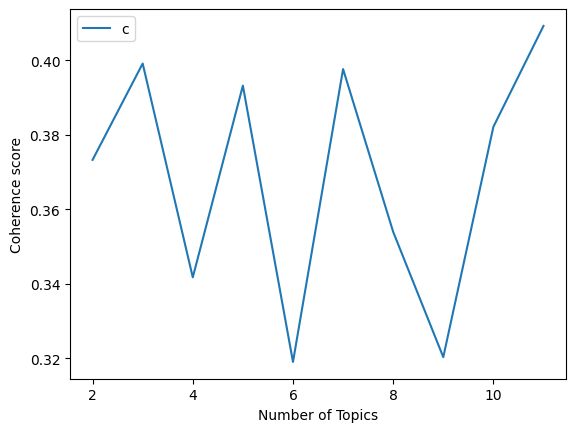

In [38]:
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()